# Cointegration & Stationarity

In this notebook we wish to explore the ideas of stationarity and then cointegration.

## Setup

First let us import the [`data_loader.py`](data_loader.py) functions and demonstrate how returns are approximately stationary compared to prices.

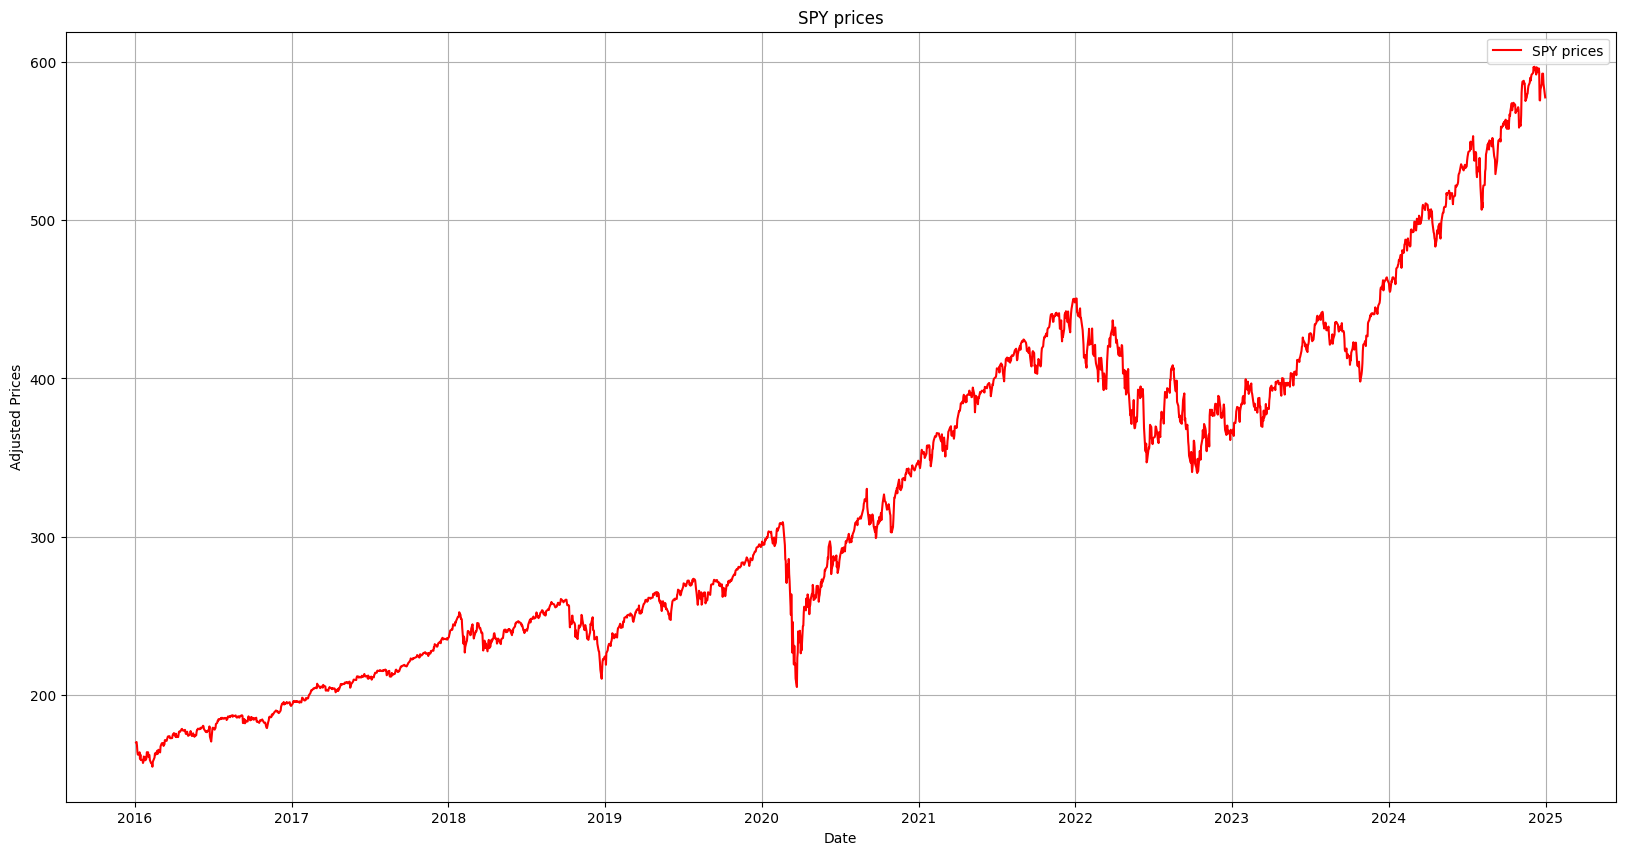

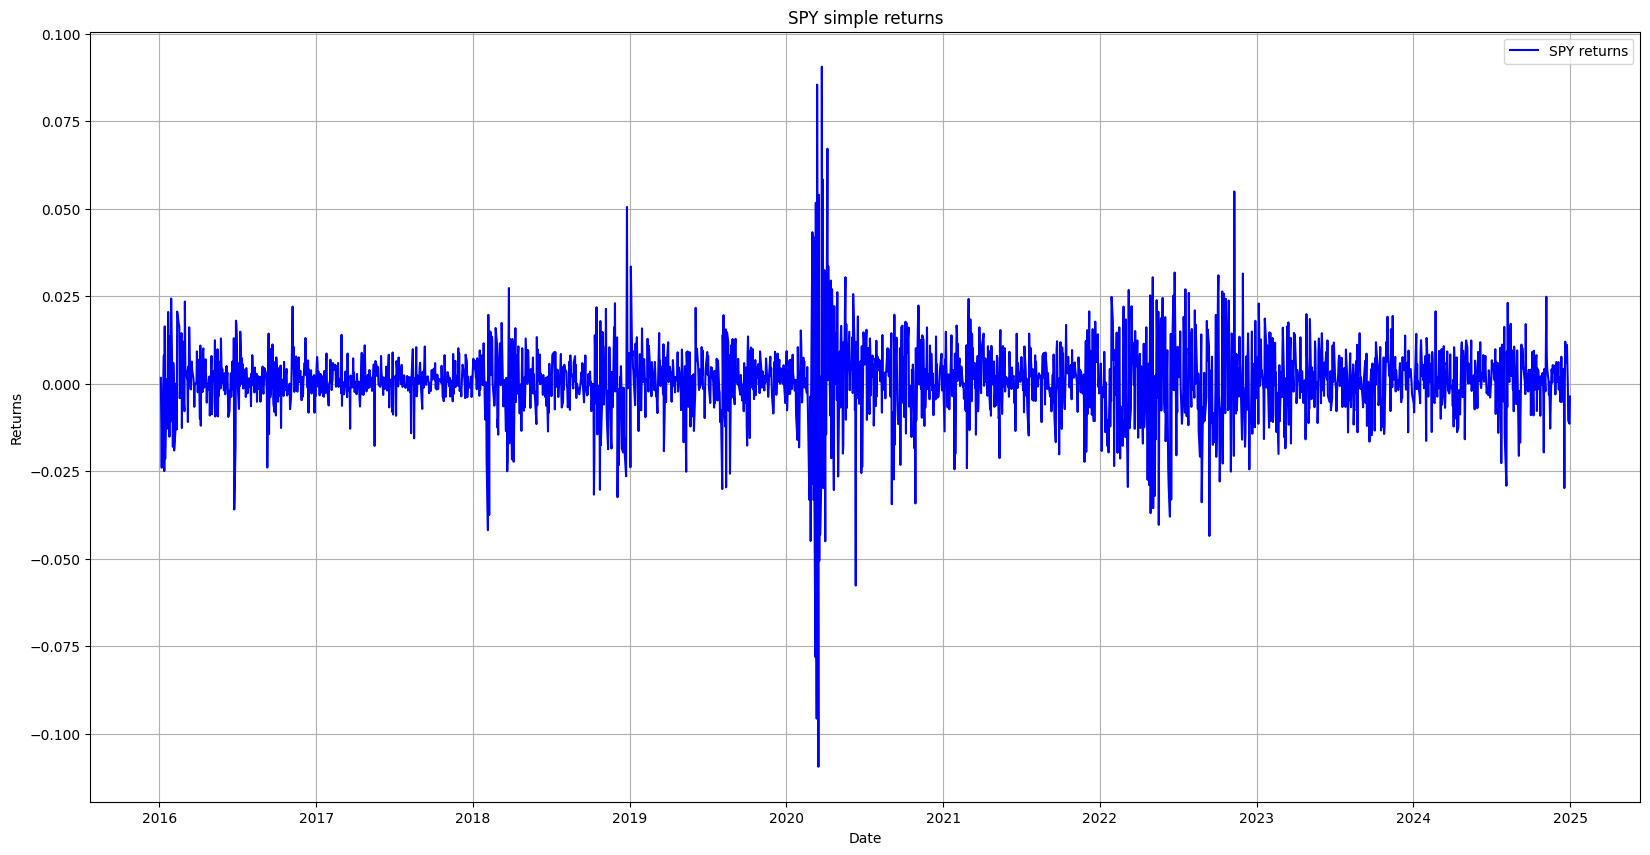

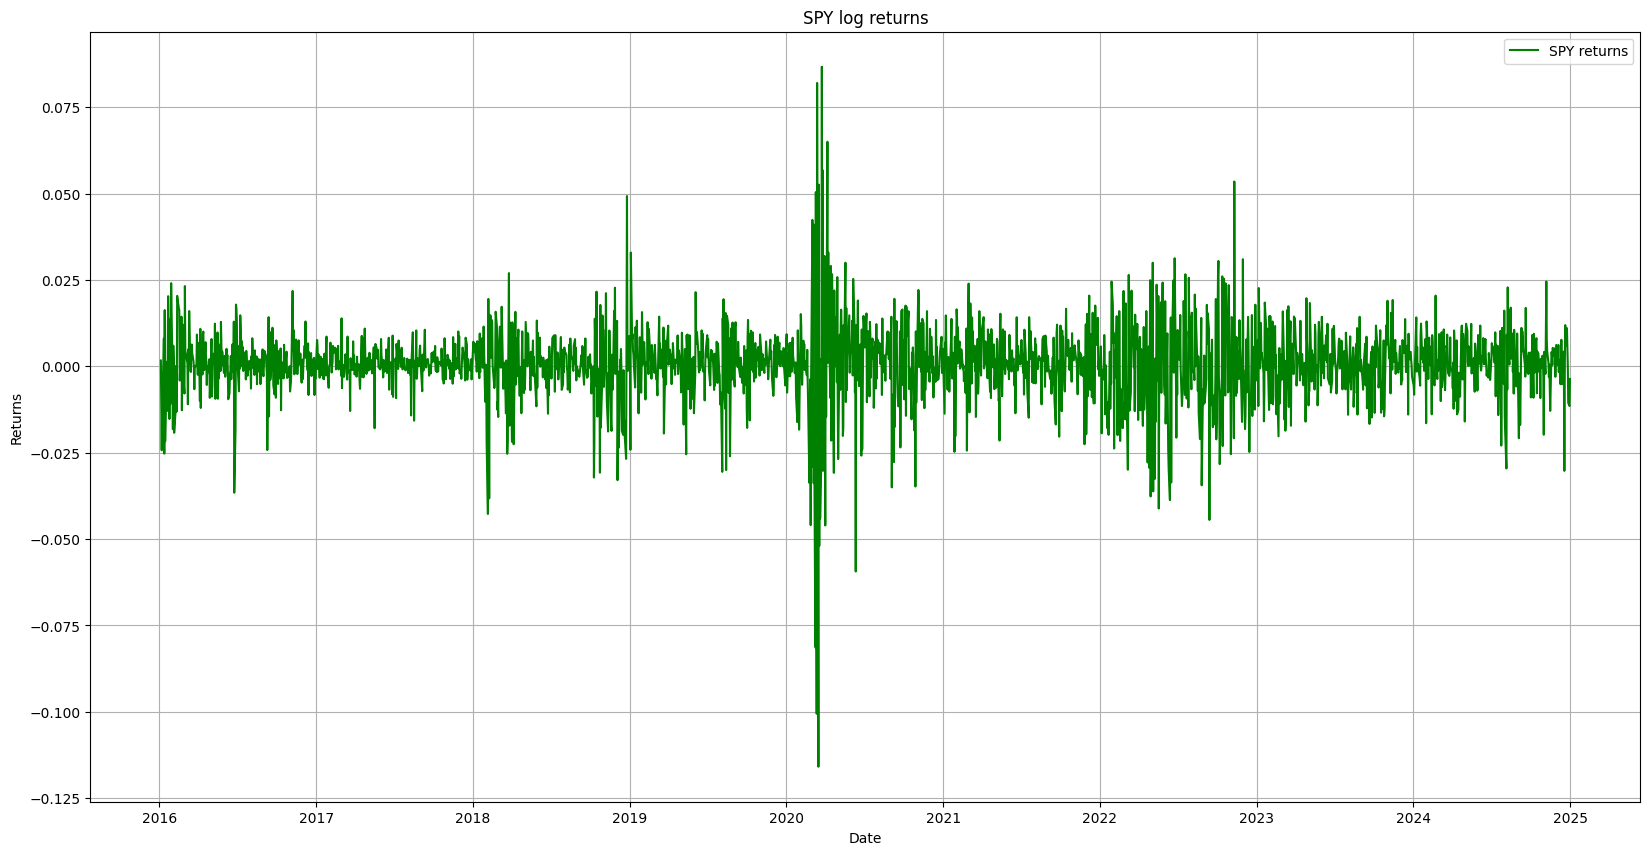

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent # parent dir
sys.path.insert(0,str(project_root/"src"))

from data_loader import download_prices, compute_returns, get_universe
from cointegration import adf_test, engle_granger_test, ols_hedge_ratio, half_life
from statsmodels.tsa.stattools import coint



prices_spy = download_prices(['SPY'],'2016-01-01','2025-01-01')

returns_spy = compute_returns(prices_spy,method='simple')
returns_log_spy = compute_returns(prices_spy,method='log')


plt.figure(figsize=(20,10))
plt.plot(prices_spy, label='SPY prices', color='red',)
plt.title('SPY prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Prices')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(20,10))
plt.plot(returns_spy, label='SPY returns', color='blue')
plt.title('SPY simple returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(20,10))
plt.plot(returns_log_spy, label='SPY returns', color='green')
plt.title('SPY log returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

The significant observation from the above plots is that both log and simple returns appear stationary whereas prices are non-stationary. This represents the idea that prices are integrated of order one (I(1)) since differencing prices gives returns.

## Sanity Checks

In order to check that the code in [`cointegration.py`](cointegration.py) works as intended, we test it here on US bank prices and returns. We expect prices should be non-stationary and generally, returns should be stationary.

In [3]:
# Load banks
prices_banks_etfs = download_prices(get_universe('banks')+get_universe('etf_pairs'),'2015-01-01', '2024-12-31')

returns_banks_etfs = compute_returns(prices_banks_etfs, method='log')

for ticker in prices_banks_etfs.columns:
    result = adf_test(prices_banks_etfs[ticker])
    print(f"{ticker} prices: stat={result['statistic']:+6.3f}  p={result['p_value']:.4f}  stationary: {result['is_stationary']}")    
print()

for ticker in returns_banks_etfs.columns:
    result = adf_test(returns_banks_etfs[ticker])
    print(f"{ticker} returns: stat={result['statistic']:+6.3f}  p={result['p_value']:.4f}  stationary: {result['is_stationary']}")

JPM prices: stat=+0.856  p=0.9925  stationary: False
BAC prices: stat=-1.228  p=0.6613  stationary: False
C prices: stat=-2.466  p=0.1240  stationary: False
WFC prices: stat=-1.174  p=0.6849  stationary: False
GS prices: stat=+1.244  p=0.9963  stationary: False
MS prices: stat=+0.331  p=0.9787  stationary: False
SPY prices: stat=+0.759  p=0.9909  stationary: False
IVV prices: stat=+0.771  p=0.9911  stationary: False
QQQ prices: stat=+1.091  p=0.9951  stationary: False
XLK prices: stat=+1.242  p=0.9963  stationary: False

JPM returns: stat=-13.224  p=0.0000  stationary: True
BAC returns: stat=-15.965  p=0.0000  stationary: True
C returns: stat=-9.494  p=0.0000  stationary: True
WFC returns: stat=-16.196  p=0.0000  stationary: True
GS returns: stat=-17.152  p=0.0000  stationary: True
MS returns: stat=-15.649  p=0.0000  stationary: True
SPY returns: stat=-15.726  p=0.0000  stationary: True
IVV returns: stat=-15.692  p=0.0000  stationary: True
QQQ returns: stat=-16.246  p=0.0000  stationar

From the above results, we see that all prices are non-stationary and we can conclude that the corresponding returns are stationary.

Next we check the naive spread of our highest price-correlated pair from `data.ipynb`, which is MS and GS. We will run the ADF test on this spread to check if the spread is stationary.

In [4]:
spread = prices_banks_etfs['MS'] - prices_banks_etfs['GS']
spread_results = adf_test(spread)
print(f"MS - GS spread results: p={spread_results['p_value']:.8f} stationary: {spread_results['is_stationary']}")

MS - GS spread results: p=0.99666175 stationary: False


We can also check the IVV and SPY spread as in `data.ipynb` where we saw that there was a noticeable downwards trend post 2016. This allows us to speculate that the result should be non-stationary with a high p-value.

In [5]:
spread_etfs = prices_banks_etfs['SPY'] - prices_banks_etfs['IVV']
spread_results_etfs = adf_test(spread_etfs)
print(f"SPY - IVV spread results: p={spread_results_etfs['p_value']:.8f} stationary: {spread_results_etfs['is_stationary']}")

SPY - IVV spread results: p=0.99672639 stationary: False


## Cointegration Test

Below we run the Engle-Granger test implemented in [`cointegration.py`](cointegration.py) on the MS, GS pair that had the highest price correlation to explore whether or not the pair is cointegrated.


In [6]:
prices_banks = download_prices(get_universe('banks'), '2015-01-01', '2025-12-31')

result = engle_granger_test(prices_banks['MS'], prices_banks['GS'])
print(f"Personal Engle-Granger implementation: beta={result['beta']:.4f} ADF stat={result['adf_statistic']:.4f} p={result['adf_p_value']:.4f} Cointegrated={result['is_cointegrated']}.")

# Library implementation with proper EG critical values.
coint_stat, coint_p, coint_crit = coint(prices_banks['MS'], prices_banks['GS'])
print(f"sm.coint: ADF stat={coint_stat:.4f}  p={coint_p:.4f}  crit values (1%, 5%, 10%): {coint_crit}")


Personal Engle-Granger implementation: beta=0.2166 ADF stat=-1.8795 p=0.3418 Cointegrated=False.
sm.coint: ADF stat=-1.8806  p=0.5898  crit values (1%, 5%, 10%): [-3.90040673 -3.33834149 -3.0459848 ]


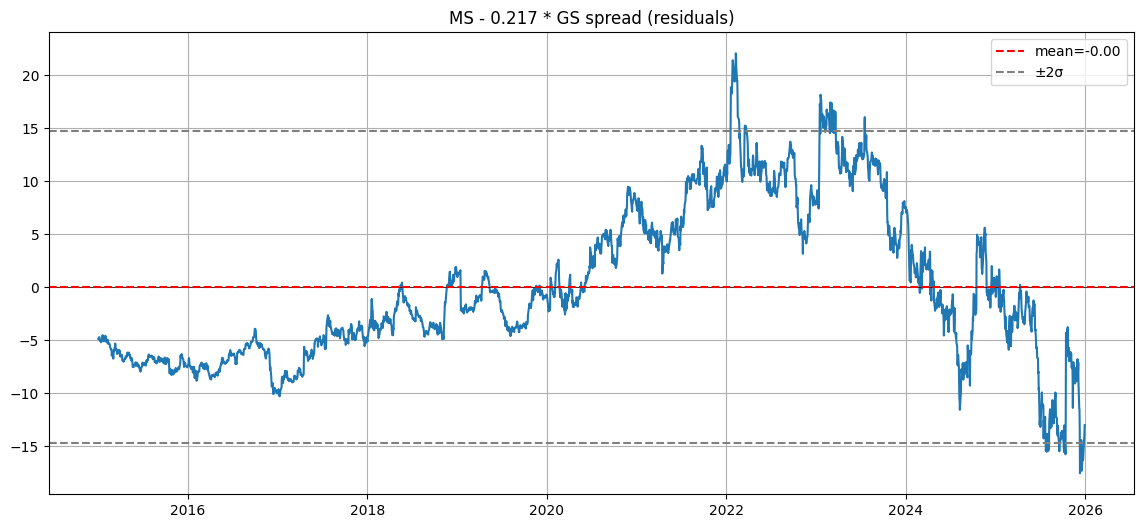

In [7]:
residuals = result['residuals']

plt.figure(figsize=(14, 6))
plt.plot(residuals)
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(residuals.mean(), color='red', linestyle='--', label=f'mean={residuals.mean():.2f}')
plt.axhline(residuals.mean() + 2*residuals.std(), color='gray', linestyle='--', label='±2σ')
plt.axhline(residuals.mean() - 2*residuals.std(), color='gray', linestyle='--')
plt.title(f'MS - {result["beta"]:.3f} * GS spread (residuals)')
plt.legend()
plt.grid(True)
plt.show()

From the cointegration values as well as the above plot we can clearly conclude that even with a highly price correlated pair like MS, GS cointegration is not guaranteed.

Next, we will run the cointegration process on many pairs to see if any such pairs are in fact cointegrated.

In [15]:
candidates = [
    ('JPM', 'BAC'),
    ('C', 'BAC'),
    ('SPY', 'IVV'),
    ('KO', 'PEP'), # The canonical example
    ('BHP', 'RIO'), # Both have majority stakes in eachother
    ('EWA', 'EWC') # Historically cointegrated from 2003-2008
]
tickers = ['JPM', 'C', 'BAC', 'SPY', 'IVV', 'KO', 'PEP', 'BHP', 'RIO', 'EWA', 'EWC']

prices_c = download_prices(tickers, '2003-01-01', '2010-12-31')

for y,x in candidates:
    result = engle_granger_test(prices_c[y], prices_c[x])
    stat, p, _ = coint(prices_c[y], prices_c[x])
    half = half_life(result['residuals'])
    print(f"{y}-{x:5s}  beta={result['beta']:+7.4f}  "
      f"my_p={result['adf_p_value']:.4f}  EG_p={p:.4f}  "
      f"R²={result['r_squared']:.3f} half life={half:.2f}")

JPM-BAC    beta=+0.1423  my_p=0.0976  EG_p=0.2500  R²=0.077 half life=74.16
C-BAC    beta=+12.4376  my_p=0.3144  EG_p=0.5611  R²=0.860 half life=127.88
SPY-IVV    beta=+0.9953  my_p=0.0230  EG_p=0.0797  R²=1.000 half life=0.92
KO-PEP    beta=+0.3494  my_p=0.7999  EG_p=0.9250  R²=0.704 half life=244.58
BHP-RIO    beta=+0.9042  my_p=0.7468  EG_p=0.8975  R²=0.753 half life=353.58
EWA-EWC    beta=+0.6020  my_p=0.0180  EG_p=0.0640  R²=0.967 half life=30.15


We see that the lowest p-value pair is EWA, EWC with an Engle-Granger p-value of 0.0640. In order to have an idea of what this implies for the cointegration, we visually plot the spread with the hedge ratio below.

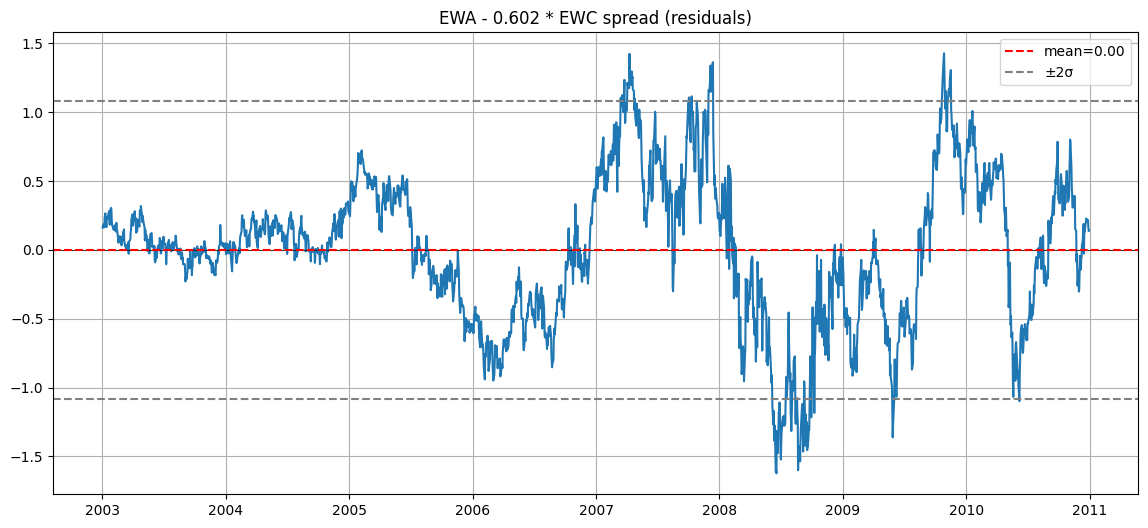

In [11]:
result = engle_granger_test(prices_c['EWA'], prices_c['EWC'])
residuals = result['residuals']

plt.figure(figsize=(14, 6))
plt.plot(residuals)
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(residuals.mean(), color='red', linestyle='--', label=f'mean={residuals.mean():.2f}')
plt.axhline(residuals.mean() + 2*residuals.std(), color='gray', linestyle='--', label='±2σ')
plt.axhline(residuals.mean() - 2*residuals.std(), color='gray', linestyle='--')
plt.title(f'EWA - {result["beta"]:.3f} * EWC spread (residuals)')
plt.legend()
plt.grid(True)
plt.show()

From the above statistics we have discovered two key points. Firstly, the EWA, EWC pair can be considered cointegrated since the custom p-value is 0.018 and the Engle-Granger p-value is 0.064. Next, we also note that the half-life is approximately 30 days. Both of these facts together imply this is a highly tradeable pair for the pairs trading strategy. Additionally, we note the even though the SPY, IVV has low p-values, the half-life value of 0.92 implies the spread reverts too fast to be traded. This is an effect of both etfs tracking the same index.